findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font famil

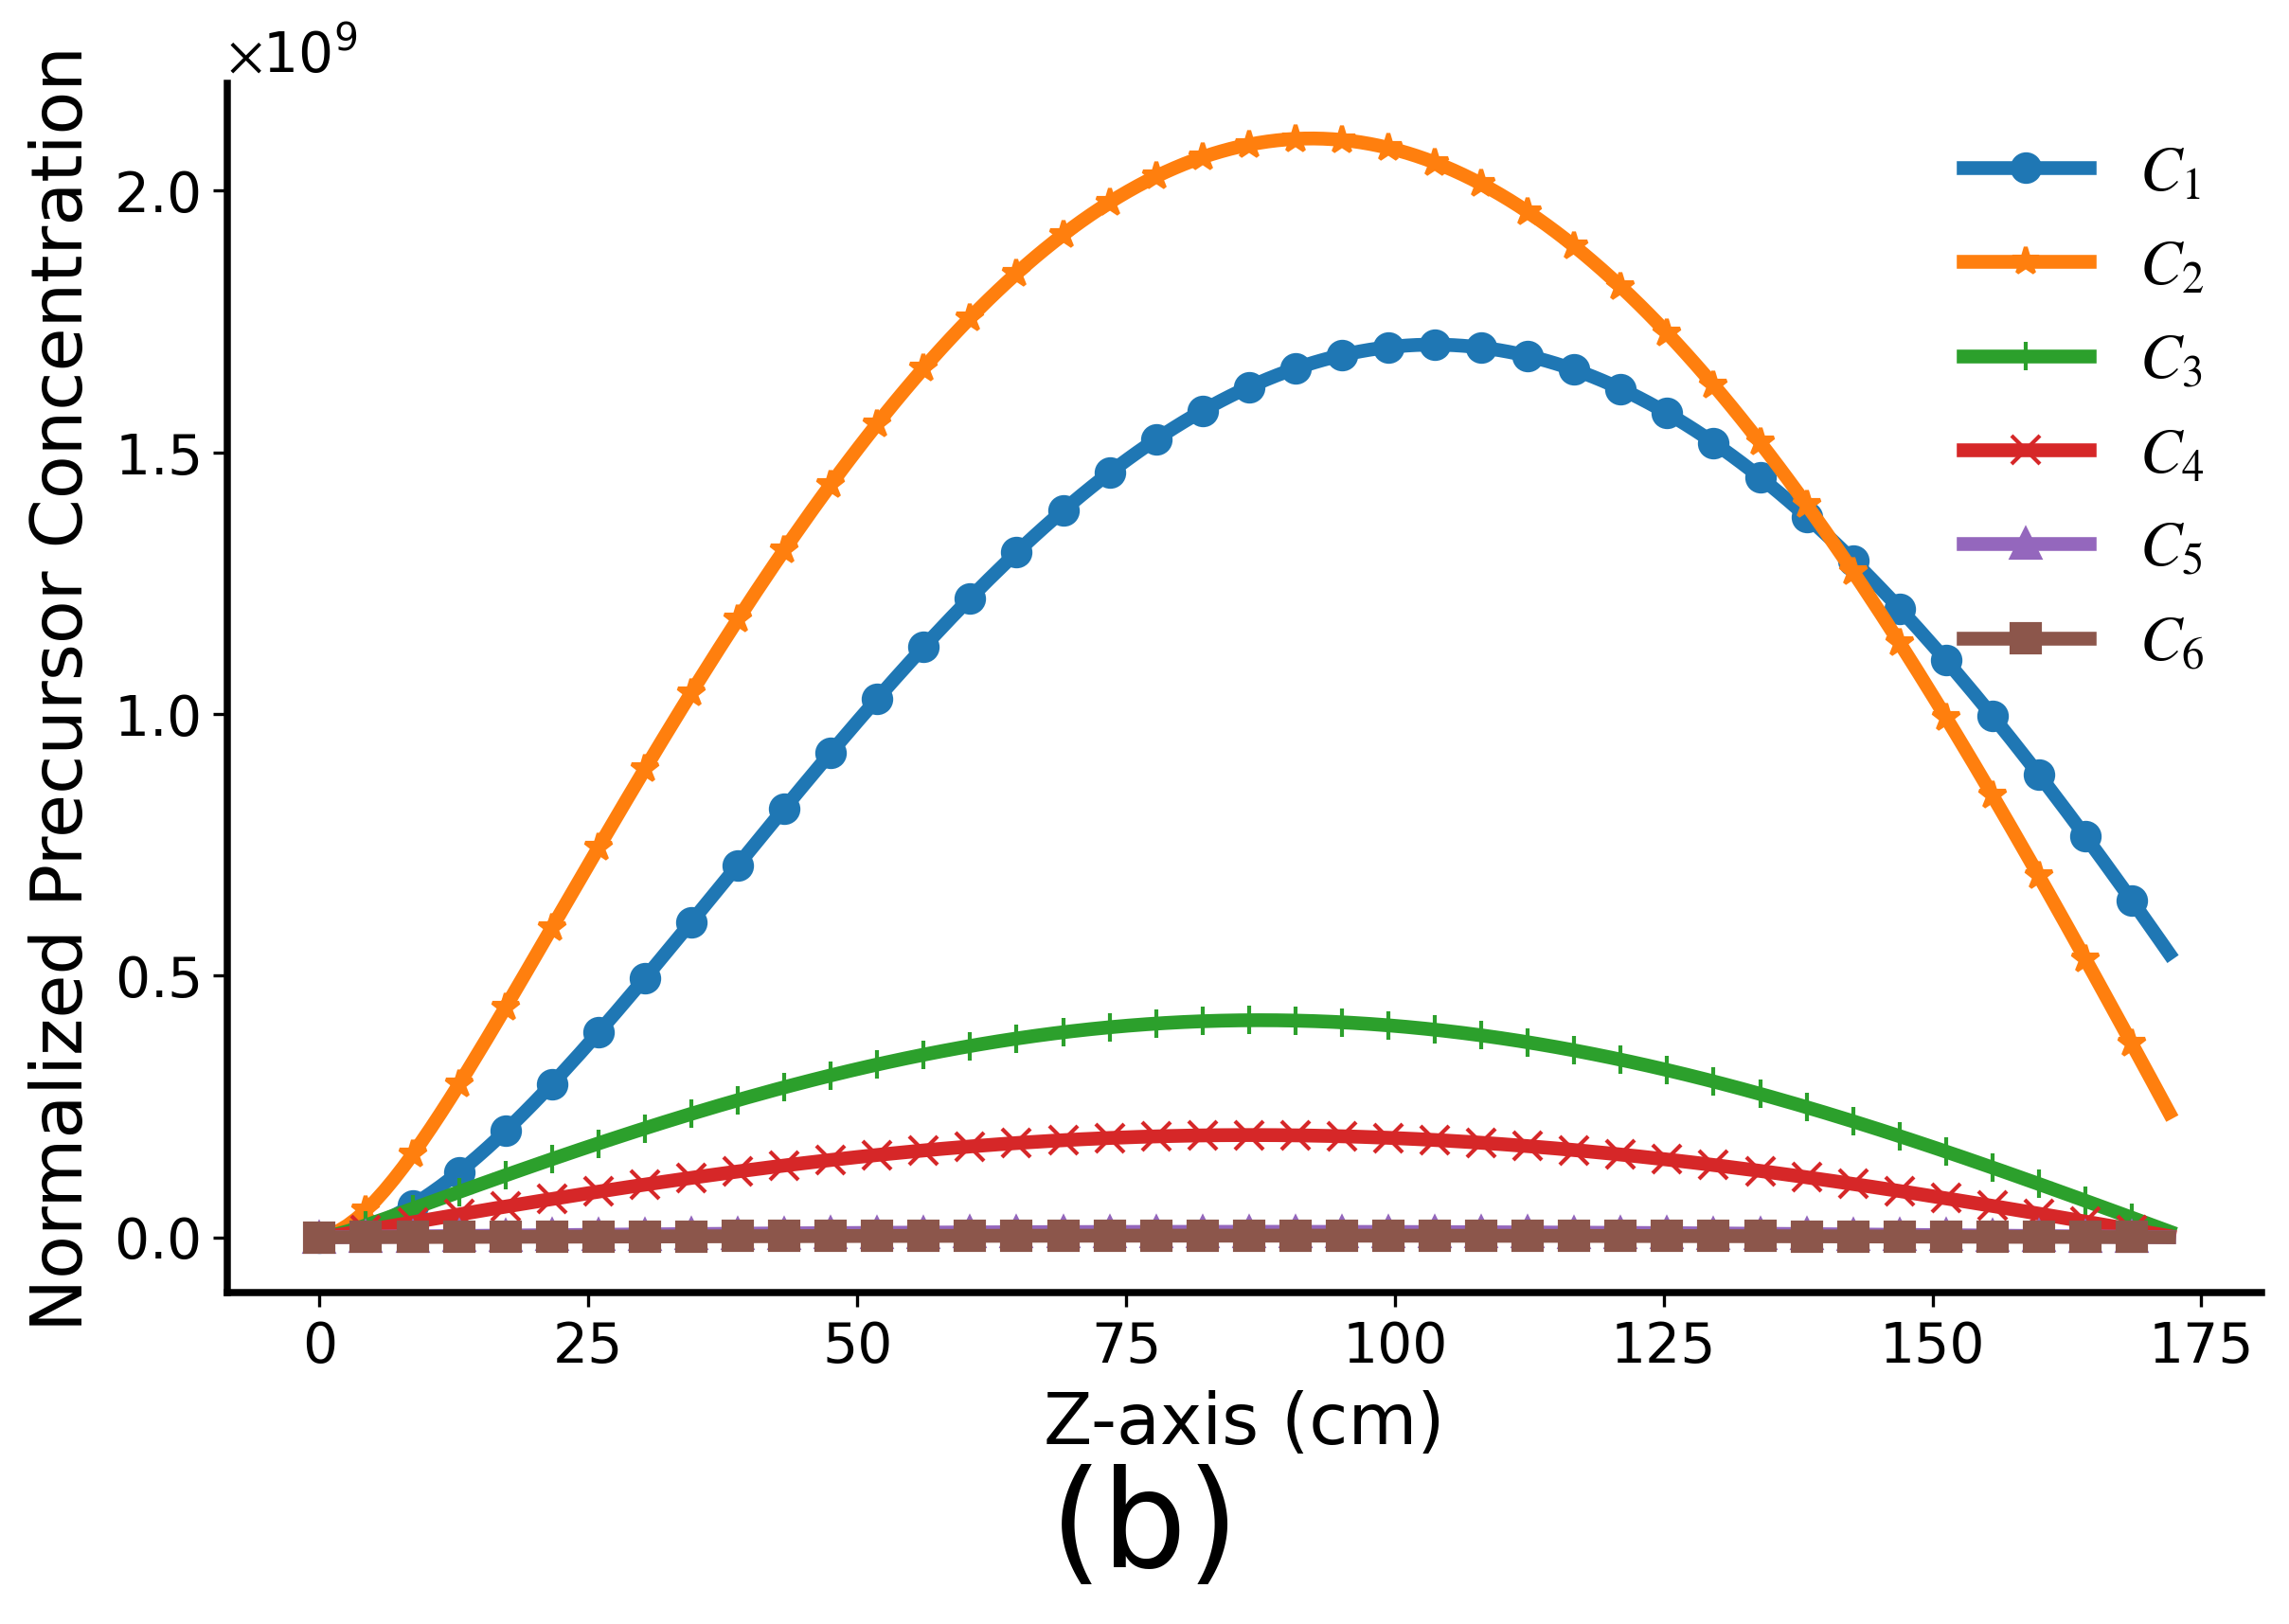

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ====== 1. 读取CSV ======
csv_path = "simulation_results/ci_groups_step_599_sim_0.csv"   # 改成你的文件名
df = pd.read_csv(csv_path)

# 只保留最后一个 step（虽然你说已经是 599，但保险起见）
last_step = df["step"].max()
df = df[df["step"] == last_step].copy()

df[["C1","C2","C3","C4","C5","C6"]] = df[["C1","C2","C3","C4","C5","C6"]].clip(lower=0)

# 按 z 排序（非常重要）
df = df.sort_values("z")

z = df["z"].to_numpy()

# ====== 2. 画图风格设置 ======
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.linewidth": 1.8,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(8.5, 5.8), dpi=300)

curves = [
    ("C1", r"$C_1$", "o"),
    ("C2", r"$C_2$", "*"),
    ("C3", r"$C_3$", "+"),
    ("C4", r"$C_4$", "x"),
    ("C5", r"$C_5$", "^"),
    ("C6", r"$C_6$", "s"),
]

for col, label, mk in curves:
    ax.plot(
        z,
        df[col].to_numpy(),
        linewidth=3.5,
        marker=mk,
        markersize=7,
        markevery=max(len(z)//40, 1),
        label=label
    )

ax.set_xlabel("Z-axis (cm)")
ax.set_ylabel("Normalized Precursor Concentration")

# 科学计数法 ×10^n
sf = ScalarFormatter(useMathText=True)
sf.set_scientific(True)
sf.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(sf)

# 去掉上右边框（论文风）
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(loc="upper right", frameon=False)

# (b)
fig.text(0.5, 0.02, "(b)", ha="center", fontsize=34)

fig.tight_layout(rect=[0.02, 0.06, 0.98, 0.98])

# ====== 导出为 PPT 可编辑矢量图 ======
fig.savefig("figure6b.svg", transparent=True)
fig.savefig("figure6b.pdf", transparent=True)
fig.savefig("figure6b.png", dpi=600, transparent=True)

plt.show()


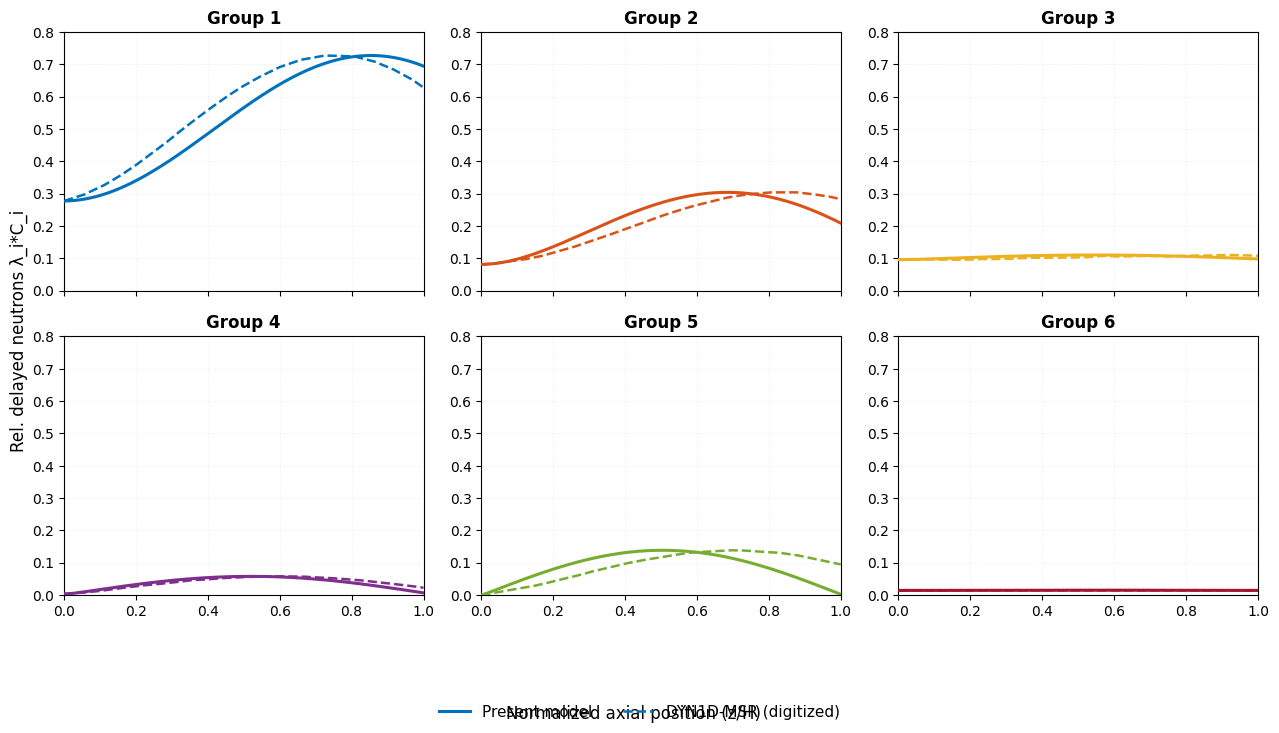

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. 更新后的 Reference 数据整理
# -----------------------------
ref_points = {}
ref_points["C1"] = np.array([(0.444649, 0.276985), (1.536370, 0.297003), (2.628662, 0.326323), (3.528583, 0.356793), (4.396613, 0.390221), (6.004483, 0.458790), (6.776437, 0.494583), (7.580440, 0.529968), (8.384349, 0.563831), (9.252486, 0.599014), (10.024024, 0.628002), (11.084531, 0.662050), (12.144751, 0.691402), (13.300778, 0.714013), (14.605902, 0.727167), (16.188015, 0.724341), (17.277537, 0.708469), (18.334426, 0.683452), (19.326815, 0.652686), (19.940443, 0.628037)])
ref_points["C2"] = np.array([(0.956738, 0.084801), (2.596332, 0.097800), (3.481253, 0.107794), (5.265376, 0.136516), (6.192018, 0.154407), (7.205811, 0.173835), (7.880191, 0.187532), (9.190416, 0.214144), (10.031805, 0.231560), (11.059292, 0.250149), (11.797739, 0.262542), (13.577039, 0.287328), (14.314242, 0.294372), (15.146330, 0.299558), (16.021121, 0.303765), (17.429140, 0.303716), (18.487126, 0.296622), (19.304548, 0.289284), (19.821239, 0.282617), (0.102987, 0.080748)])
ref_points["C3"] = np.array([(0.754277, 0.095742), (1.235367, 0.095564), (1.973115, 0.096542), (2.999403, 0.095564), (3.705017, 0.095564), (4.362521, 0.095564), (5.276732, 0.097520), (5.950273, 0.097520), (6.784229, 0.098303), (7.778695, 0.101434), (8.901264, 0.101434), (9.606908, 0.101923), (10.055945, 0.102086), (10.889933, 0.103391), (11.820301, 0.107304), (12.493722, 0.105348), (13.428491, 0.106326), (14.097493, 0.107025), (15.091695, 0.105837), (16.727581, 0.108185), (17.433201, 0.108283), (18.395503, 0.109913), (19.069003, 0.109261), (20.055617, 0.107664)])
ref_points["C4"] = np.array([(1.492961, 0.007313), (2.404181, 0.012792), (3.796831, 0.023652), (4.823598, 0.030501), (5.600032, 0.034708), (6.459940, 0.040285), (7.262119, 0.045910), (7.903692, 0.047623), (8.988072, 0.052515), (9.822111, 0.054667), (10.656127, 0.056428), (11.490095, 0.057407), (12.073830, 0.057407), (13.157850, 0.056428), (13.965934, 0.053738), (14.735561, 0.051536), (15.659010, 0.047231), (16.242590, 0.044687), (17.268518, 0.037839), (18.102096, 0.032458), (18.999761, 0.026098), (19.480622, 0.022185), (0.441360, 0.002991)])
ref_points["C5"] = np.array([(0.987190, 0.008487), (2.995310, 0.028766), (3.637300, 0.037295), (5.627572, 0.065412), (6.012861, 0.072082), (7.970966, 0.098662), (8.933817, 0.109261), (11.180236, 0.130199), (11.661452, 0.132090), (13.515663, 0.138124), (14.131427, 0.137390), (16.130213, 0.129970), (17.081233, 0.121980), (19.356758, 0.094477), (0.098039, 0)])
ref_points["C6"] = np.array([(0.813437, 0.014357), (1.262484, 0.014684), (3.158331, 0.013923), (3.796261, 0.014357), (4.758462, 0.014357), (5.624444, 0.014357), (6.714938, 0.014357), (7.484699, 0.014357), (8.594438, 0.014357), (9.192607, 0.014357), (10.210936, 0.014357), (11.205211, 0.014357), (11.814605, 0.014357), (13.322054, 0.014357), (14.027668, 0.014357), (14.669136, 0.014357), (15.663410, 0.014357), (16.721832, 0.014357), (17.395373, 0.014357), (18.357574, 0.014357), (19.544289, 0.014357)])

# -----------------------------
# 2. 样式与数据加载
# -----------------------------
colors = {"C1":[0,0.4470,0.7410], "C2":[0.8500,0.3250,0.0980], "C3":[0.9290,0.6940,0.1250], "C4":[0.4940,0.1840,0.5560], "C5":[0.4660,0.6740,0.1880], "C6":[0.6350,0.0780,0.1840]}

df_model = pd.read_csv('simulation_results/ci_groups_step_599_sim_0.csv')
last_sim = df_model['simulation_index'].max()
df_plot = df_model[df_model['simulation_index'] == last_sim].sort_values('z')

groups = ["C1", "C2", "C3", "C4", "C5", "C6"]
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True)
axes = axes.ravel()

# -----------------------------
# 3. 核心绘图逻辑
# -----------------------------
for i, g in enumerate(groups):
    ax = axes[i]
    
    # Ref 数据处理
    ref_arr = ref_points[g]
    ref_arr = ref_arr[ref_arr[:, 0].argsort()] # 排序
    rx_norm = (ref_arr[:,0] - ref_arr[:,0].min()) / (ref_arr[:,0].max() - ref_arr[:,0].min())
    ry = ref_arr[:,1]
    
    # Model 数据处理
    mx_raw = df_plot['z'].values
    my_raw = df_plot[g].values
    mx_norm = (mx_raw - mx_raw.min()) / (mx_raw.max() - mx_raw.min())
    
    # 纵坐标对齐
    rmin, rmax = ry.min(), ry.max()
    mmin, mmax = my_raw.min(), my_raw.max()
    my_scaled = (my_raw - mmin) / (mmax - mmin) * (rmax - rmin) + rmin if mmax != mmin else my_raw

    # 绘图
    ax.plot(mx_norm, my_scaled, color=colors[g], linewidth=2.2, label="Present model", zorder=3)
    ax.plot(rx_norm, ry, color=colors[g], linewidth=1.8, linestyle="--", label="DYN1D-MSR (digitized)", zorder=2)

    # # 峰值标记
    # ax.scatter(mx_norm[np.argmax(my_scaled)], np.max(my_scaled), color=colors[g], s=25, zorder=4)
    # ax.scatter(rx_norm[np.argmax(ry)], np.max(ry), facecolors='none', edgecolors=colors[g], s=25, zorder=4)

    # 子图细节
    ax.set_title(f"Group {g[-1]}", fontsize=12, fontweight='bold')
    ax.set_ylim(0, 0.8)
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.2, linestyle=':')

# -----------------------------
# 4. 全局修饰
# -----------------------------
# fig.suptitle("Axial Delayed Neutron Precursor Groups — Model vs DYN1D-MSR", fontsize=14)
fig.supxlabel("Normalized axial position (z/H)", fontsize=12)
fig.supylabel("Rel. delayed neutrons λ_i*C_i", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, fontsize=11)

plt.tight_layout(rect=[0, 0.08, 1, 0.92])
plt.show()

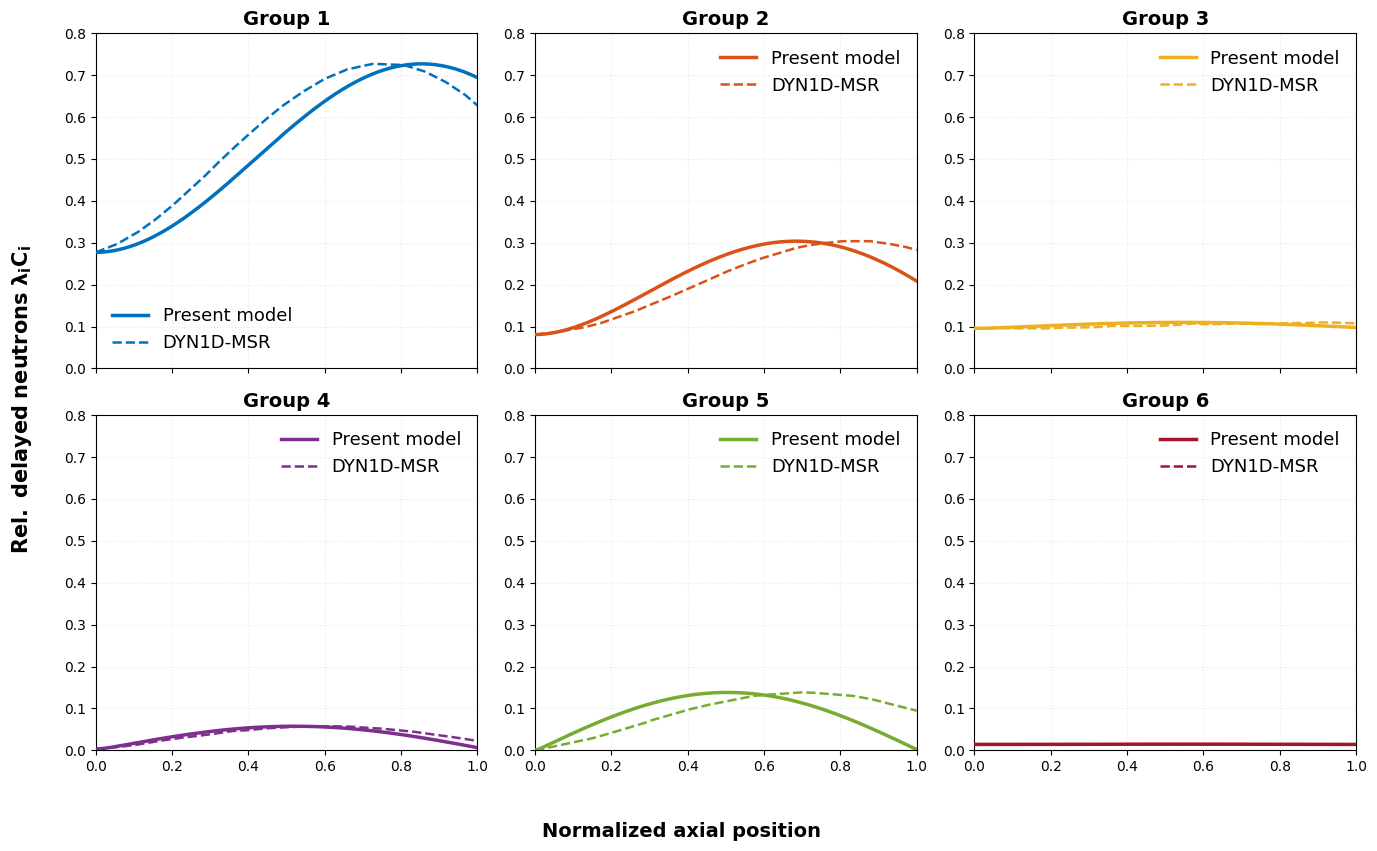

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. 数据准备 (保持不变)
# -----------------------------
ref_points = {
    "C1": np.array([(0.444649, 0.276985), (1.536370, 0.297003), (2.628662, 0.326323), (3.528583, 0.356793), (4.396613, 0.390221), (6.004483, 0.458790), (6.776437, 0.494583), (7.580440, 0.529968), (8.384349, 0.563831), (9.252486, 0.599014), (10.024024, 0.628002), (11.084531, 0.662050), (12.144751, 0.691402), (13.300778, 0.714013), (14.605902, 0.727167), (16.188015, 0.724341), (17.277537, 0.708469), (18.334426, 0.683452), (19.326815, 0.652686), (19.940443, 0.628037)]),
    "C2": np.array([(0.956738, 0.084801), (2.596332, 0.097800), (3.481253, 0.107794), (5.265376, 0.136516), (6.192018, 0.154407), (7.205811, 0.173835), (7.880191, 0.187532), (9.190416, 0.214144), (10.031805, 0.231560), (11.059292, 0.250149), (11.797739, 0.262542), (13.577039, 0.287328), (14.314242, 0.294372), (15.146330, 0.299558), (16.021121, 0.303765), (17.429140, 0.303716), (18.487126, 0.296622), (19.304548, 0.289284), (19.821239, 0.282617), (0.102987, 0.080748)]),
    "C3": np.array([(0.754277, 0.095742), (1.235367, 0.095564), (1.973115, 0.096542), (2.999403, 0.095564), (3.705017, 0.095564), (4.362521, 0.095564), (5.276732, 0.097520), (5.950273, 0.097520), (6.784229, 0.098303), (7.778695, 0.101434), (8.901264, 0.101434), (9.606908, 0.101923), (10.055945, 0.102086), (10.889933, 0.103391), (11.820301, 0.107304), (12.493722, 0.105348), (13.428491, 0.106326), (14.097493, 0.107025), (15.091695, 0.105837), (16.727581, 0.108185), (17.433201, 0.108283), (18.395503, 0.109913), (19.069003, 0.109261), (20.055617, 0.107664)]),
    "C4": np.array([(1.492961, 0.007313), (2.404181, 0.012792), (3.796831, 0.023652), (4.823598, 0.030501), (5.600032, 0.034708), (6.459940, 0.040285), (7.262119, 0.045910), (7.903692, 0.047623), (8.988072, 0.052515), (9.822111, 0.054667), (10.656127, 0.056428), (11.490095, 0.057407), (12.073830, 0.057407), (13.157850, 0.056428), (13.965934, 0.053738), (14.735561, 0.051536), (15.659010, 0.047231), (16.242590, 0.044687), (17.268518, 0.037839), (18.102096, 0.032458), (18.999761, 0.026098), (19.480622, 0.022185), (0.441360, 0.002991)]),
    "C5": np.array([(0.987190, 0.008487), (2.995310, 0.028766), (3.637300, 0.037295), (5.627572, 0.065412), (6.012861, 0.072082), (7.970966, 0.098662), (8.933817, 0.109261), (11.180236, 0.130199), (11.661452, 0.132090), (13.515663, 0.138124), (14.131427, 0.137390), (16.130213, 0.129970), (17.081233, 0.121980), (19.356758, 0.094477), (0.098039, 0)]),
    "C6": np.array([(0.813437, 0.014357), (1.262484, 0.014684), (3.158331, 0.013923), (3.796261, 0.014357), (4.758462, 0.014357), (5.624444, 0.014357), (6.714938, 0.014357), (7.484699, 0.014357), (8.594438, 0.014357), (9.192607, 0.014357), (10.210936, 0.014357), (11.205211, 0.014357), (11.814605, 0.014357), (13.322054, 0.014357), (14.027668, 0.014357), (14.669136, 0.014357), (15.663410, 0.014357), (16.721832, 0.014357), (17.395373, 0.014357), (18.357574, 0.014357), (19.544289, 0.014357)])
}

# -----------------------------
# 2. 样式设置
# -----------------------------
colors = {"C1":[0,0.4470,0.7410], "C2":[0.8500,0.3250,0.0980], "C3":[0.9290,0.6940,0.1250], "C4":[0.4940,0.1840,0.5560], "C5":[0.4660,0.6740,0.1880], "C6":[0.6350,0.0780,0.1840]}

# 数据文件加载 (注意根据你的实际路径调整)
df_model = pd.read_csv('simulation_results/ci_groups_step_599_sim_0.csv') 
last_sim = df_model['simulation_index'].max()
df_plot = df_model[df_model['simulation_index'] == last_sim].sort_values('z')

groups = ["C1", "C2", "C3", "C4", "C5", "C6"]
fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True)
axes = axes.ravel()

# -----------------------------
# 3. 循环绘图
# -----------------------------
for i, g in enumerate(groups):
    ax = axes[i]
    
    # --- Reference 曲线 ---
    ref_arr = ref_points[g]
    ref_arr = ref_arr[ref_arr[:, 0].argsort()]
    rx_norm = (ref_arr[:,0] - ref_arr[:,0].min()) / (ref_arr[:,0].max() - ref_arr[:,0].min())
    ry = ref_arr[:,1]
    
    # --- Model 曲线 ---
    mx_raw = df_plot['z'].values
    my_raw = df_plot[g].values
    mx_norm = (mx_raw - mx_raw.min()) / (mx_raw.max() - mx_raw.min())
    
    # 纵坐标对齐
    rmin, rmax = ry.min(), ry.max()
    mmin, mmax = my_raw.min(), my_raw.max()
    my_scaled = (my_raw - mmin) / (mmax - mmin) * (rmax - rmin) + rmin if mmax != mmin else my_raw

    # 绘制
    ax.plot(mx_norm, my_scaled, color=colors[g], linewidth=2.5, label="Present model", zorder=3)
    ax.plot(rx_norm, ry, color=colors[g], linewidth=1.8, linestyle="--", label="DYN1D-MSR", zorder=2)

    # 子图修饰
    ax.set_title(f"Group {g[-1]}", fontsize=14, fontweight='bold')
    ax.set_ylim(0, 0.8) # 统一纵坐标
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.25, linestyle=':')
    
    # 每张子图单独放置 legend，设置在空白处，去掉边框
    ax.legend(loc='best', fontsize=13, frameon=False)

# -----------------------------
# 4. 全局标签加粗加大
# -----------------------------
# 横轴加粗
fig.supxlabel("Normalized axial position", fontsize=14, fontweight='bold')

# 纵轴加粗 + 数学格式 (λ_i C_i)
fig.supylabel(r"$\mathbf{Rel.\ delayed\ neutrons\ \lambda_i C_i}$", fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0.02, 0.03, 1, 0.95]) # 留出标题和标签空间
plt.show()

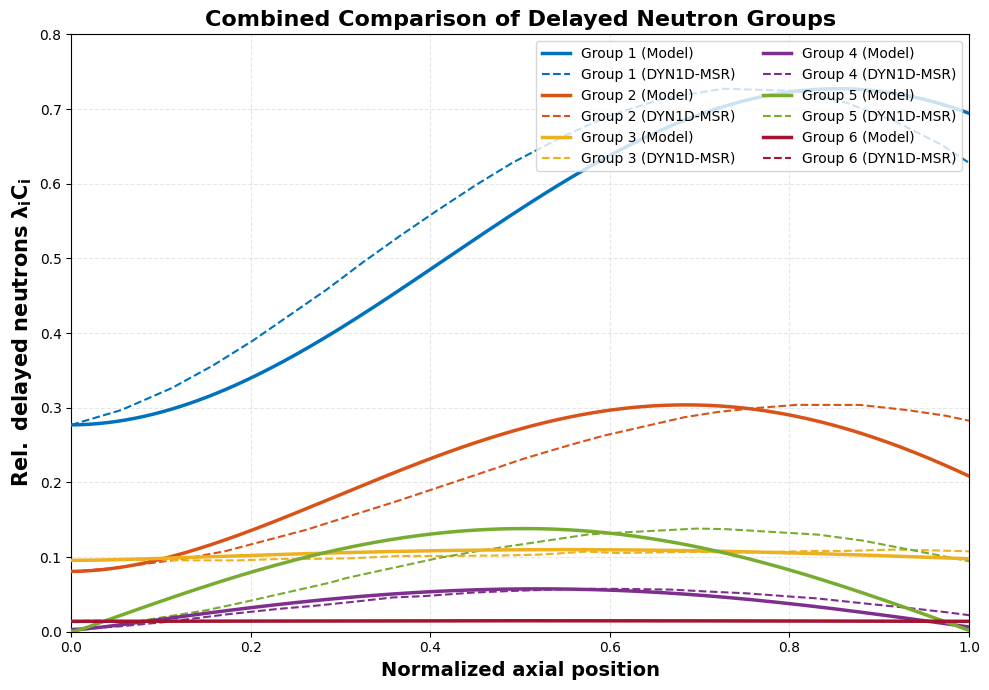

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Preparation (Kept as provided)
ref_points = {
    "C1": np.array([(0.444649, 0.276985), (1.536370, 0.297003), (2.628662, 0.326323), (3.528583, 0.356793), (4.396613, 0.390221), (6.004483, 0.458790), (6.776437, 0.494583), (7.580440, 0.529968), (8.384349, 0.563831), (9.252486, 0.599014), (10.024024, 0.628002), (11.084531, 0.662050), (12.144751, 0.691402), (13.300778, 0.714013), (14.605902, 0.727167), (16.188015, 0.724341), (17.277537, 0.708469), (18.334426, 0.683452), (19.326815, 0.652686), (19.940443, 0.628037)]),
    "C2": np.array([(0.956738, 0.084801), (2.596332, 0.097800), (3.481253, 0.107794), (5.265376, 0.136516), (6.192018, 0.154407), (7.205811, 0.173835), (7.880191, 0.187532), (9.190416, 0.214144), (10.031805, 0.231560), (11.059292, 0.250149), (11.797739, 0.262542), (13.577039, 0.287328), (14.314242, 0.294372), (15.146330, 0.299558), (16.021121, 0.303765), (17.429140, 0.303716), (18.487126, 0.296622), (19.304548, 0.289284), (19.821239, 0.282617), (0.102987, 0.080748)]),
    "C3": np.array([(0.754277, 0.095742), (1.235367, 0.095564), (1.973115, 0.096542), (2.999403, 0.095564), (3.705017, 0.095564), (4.362521, 0.095564), (5.276732, 0.097520), (5.950273, 0.097520), (6.784229, 0.098303), (7.778695, 0.101434), (8.901264, 0.101434), (9.606908, 0.101923), (10.055945, 0.102086), (10.889933, 0.103391), (11.820301, 0.107304), (12.493722, 0.105348), (13.428491, 0.106326), (14.097493, 0.107025), (15.091695, 0.105837), (16.727581, 0.108185), (17.433201, 0.108283), (18.395503, 0.109913), (19.069003, 0.109261), (20.055617, 0.107664)]),
    "C4": np.array([(1.492961, 0.007313), (2.404181, 0.012792), (3.796831, 0.023652), (4.823598, 0.030501), (5.600032, 0.034708), (6.459940, 0.040285), (7.262119, 0.045910), (7.903692, 0.047623), (8.988072, 0.052515), (9.822111, 0.054667), (10.656127, 0.056428), (11.490095, 0.057407), (12.073830, 0.057407), (13.157850, 0.056428), (13.965934, 0.053738), (14.735561, 0.051536), (15.659010, 0.047231), (16.242590, 0.044687), (17.268518, 0.037839), (18.102096, 0.032458), (18.999761, 0.026098), (19.480622, 0.022185), (0.441360, 0.002991)]),
    "C5": np.array([(0.987190, 0.008487), (2.995310, 0.028766), (3.637300, 0.037295), (5.627572, 0.065412), (6.012861, 0.072082), (7.970966, 0.098662), (8.933817, 0.109261), (11.180236, 0.130199), (11.661452, 0.132090), (13.515663, 0.138124), (14.131427, 0.137390), (16.130213, 0.129970), (17.081233, 0.121980), (19.356758, 0.094477), (0.098039, 0)]),
    "C6": np.array([(0.813437, 0.014357), (1.262484, 0.014684), (3.158331, 0.013923), (3.796261, 0.014357), (4.758462, 0.014357), (5.624444, 0.014357), (6.714938, 0.014357), (7.484699, 0.014357), (8.594438, 0.014357), (9.192607, 0.014357), (10.210936, 0.014357), (11.205211, 0.014357), (11.814605, 0.014357), (13.322054, 0.014357), (14.027668, 0.014357), (14.669136, 0.014357), (15.663410, 0.014357), (16.721832, 0.014357), (17.395373, 0.014357), (18.357574, 0.014357), (19.544289, 0.014357)])
}

colors = {"C1":[0,0.4470,0.7410], "C2":[0.8500,0.3250,0.0980], "C3":[0.9290,0.6940,0.1250], "C4":[0.4940,0.1840,0.5560], "C5":[0.4660,0.6740,0.1880], "C6":[0.6350,0.0780,0.1840]}

# Load Data
df_model = pd.read_csv('simulation_results/ci_groups_step_599_sim_0.csv') 
last_sim = df_model['simulation_index'].max()
df_plot = df_model[df_model['simulation_index'] == last_sim].sort_values('z')

groups = ["C1", "C2", "C3", "C4", "C5", "C6"]

# --- Create Single Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

# 3. Loop and Plot on the same 'ax'
for g in groups:
    # --- Reference Curve ---
    ref_arr = ref_points[g]
    ref_arr = ref_arr[ref_arr[:, 0].argsort()]
    rx_norm = (ref_arr[:,0] - ref_arr[:,0].min()) / (ref_arr[:,0].max() - ref_arr[:,0].min())
    ry = ref_arr[:,1]
    
    # --- Model Curve ---
    mx_raw = df_plot['z'].values
    my_raw = df_plot[g].values
    mx_norm = (mx_raw - mx_raw.min()) / (mx_raw.max() - mx_raw.min())
    
    # Scale model Y to match reference range (as per your original logic)
    rmin, rmax = ry.min(), ry.max()
    mmin, mmax = my_raw.min(), my_raw.max()
    my_scaled = (my_raw - mmin) / (mmax - mmin) * (rmax - rmin) + rmin if mmax != mmin else my_raw

    # Plot Model (Solid) and Reference (Dashed)
    # We only add a label for the Reference to keep the legend clean
    ax.plot(mx_norm, my_scaled, color=colors[g], linewidth=2.5, 
            label=f"Group {g[-1]} (Model)", zorder=3)
    ax.plot(rx_norm, ry, color=colors[g], linewidth=1.5, linestyle="--", 
            label=f"Group {g[-1]} (DYN1D-MSR)", zorder=2)

# --- Final Polishing ---
ax.set_xlabel("Normalized axial position", fontsize=14, fontweight='bold')
ax.set_ylabel(r"$\mathbf{Rel.\ delayed\ neutrons\ \lambda_i C_i}$", fontsize=15, fontweight='bold')
ax.set_title("Combined Comparison of Delayed Neutron Groups", fontsize=16, fontweight='bold')

ax.set_ylim(0, 0.8)
ax.set_xlim(0, 1)
ax.grid(alpha=0.3, linestyle='--')

# Place legend outside or inside
ax.legend(loc='upper right', fontsize=10, frameon=True, ncol=2)

plt.tight_layout()
plt.show()